<a href="https://colab.research.google.com/github/Lian067/Lian067/blob/main/mnist_mlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Baseline MLP for MNIST dataset**

**Importing Packages**

In [1]:
import numpy
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout
from keras.utils import to_categorical
import matplotlib.pyplot as plt
from keras.models import model_from_json
import h5py

In [2]:
seed = 7
numpy.random.seed(seed)

**load data**

In [3]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


**flatten 28x28 images to a 784 vector for each image **

In [4]:
num_pixels = X_train.shape[1] * X_train.shape[2]
print (X_train.shape)
X_train = X_train.reshape(X_train.shape[0], num_pixels).astype('float32')
X_test = X_test.reshape(X_test.shape[0], num_pixels).astype('float32')

(60000, 28, 28)


**normalize inputs from 0-255 to 0-1**

In [5]:
X_train = X_train / 255
X_test = X_test / 255

**One Hot Encoding the outputs**

In [6]:
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)
num_classes = y_test.shape[1]

**define baseline model**

In [7]:
def baseline_model():
	# create model
	model = Sequential()
	model.add(Dense(num_pixels, input_dim=num_pixels,  activation='relu'))
	model.add(Dense(num_classes,  activation='softmax'))
	# Compile model
	model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
	return model

**Build and Fit the model**

In [8]:
model = baseline_model()
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, batch_size=200, verbose=2)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
300/300 - 3s - 11ms/step - accuracy: 0.9222 - loss: 0.2779 - val_accuracy: 0.9598 - val_loss: 0.1365
Epoch 2/10
300/300 - 1s - 3ms/step - accuracy: 0.9675 - loss: 0.1124 - val_accuracy: 0.9696 - val_loss: 0.1042
Epoch 3/10
300/300 - 1s - 3ms/step - accuracy: 0.9793 - loss: 0.0727 - val_accuracy: 0.9740 - val_loss: 0.0850
Epoch 4/10
300/300 - 1s - 5ms/step - accuracy: 0.9855 - loss: 0.0512 - val_accuracy: 0.9779 - val_loss: 0.0708
Epoch 5/10
300/300 - 1s - 4ms/step - accuracy: 0.9897 - loss: 0.0369 - val_accuracy: 0.9811 - val_loss: 0.0598
Epoch 6/10
300/300 - 1s - 3ms/step - accuracy: 0.9928 - loss: 0.0272 - val_accuracy: 0.9810 - val_loss: 0.0624
Epoch 7/10
300/300 - 1s - 3ms/step - accuracy: 0.9949 - loss: 0.0197 - val_accuracy: 0.9795 - val_loss: 0.0682
Epoch 8/10
300/300 - 1s - 3ms/step - accuracy: 0.9968 - loss: 0.0146 - val_accuracy: 0.9808 - val_loss: 0.0596
Epoch 9/10
300/300 - 1s - 4ms/step - accuracy: 0.9979 - loss: 0.0106 - val_accuracy: 0.9816 - val_loss: 0.0613


**Final evaluation of the model**

In [9]:
scores = model.evaluate(X_test, y_test, verbose=0)
print("Baseline Error: %.2f%%" % (100-scores[1]*100))

Baseline Error: 1.85%


In [11]:
print(history.history)

{'accuracy': [0.9222166538238525, 0.9675333499908447, 0.9793499708175659, 0.985450029373169, 0.9896500110626221, 0.9928333163261414, 0.9949333071708679, 0.9967666864395142, 0.9979000091552734, 0.9986000061035156], 'loss': [0.27787938714027405, 0.11236027628183365, 0.07269831746816635, 0.05124823749065399, 0.03688640892505646, 0.027206238359212875, 0.0197104811668396, 0.014586429111659527, 0.01059217844158411, 0.008290928788483143], 'val_accuracy': [0.9598000049591064, 0.9696000218391418, 0.9739999771118164, 0.9779000282287598, 0.9811000227928162, 0.9810000061988831, 0.9794999957084656, 0.9807999730110168, 0.9815999865531921, 0.9815000295639038], 'val_loss': [0.1364525407552719, 0.10416030138731003, 0.08504234254360199, 0.0707777738571167, 0.059836454689502716, 0.062414538115262985, 0.06824095547199249, 0.059610698372125626, 0.061323896050453186, 0.06167740002274513]}


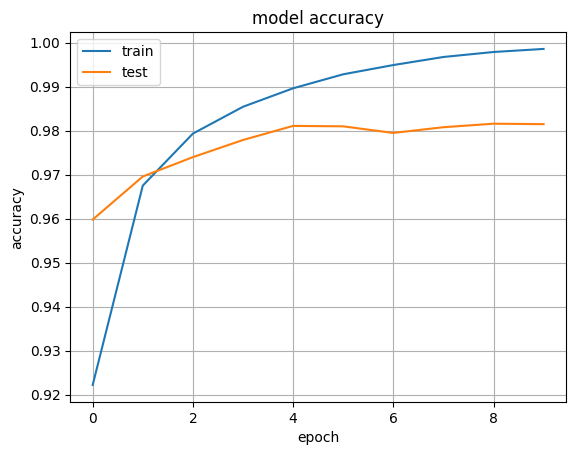

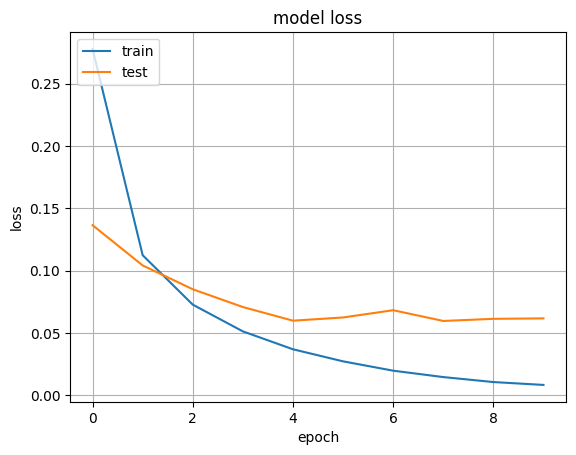

In [12]:
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.grid()
plt.show()

# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.grid()
plt.show()

In [14]:
model_json = model.to_json()
with open("final_model.json", "w") as json_file:
    json_file.write(model_json)
# serialize weights to HDF5
model.save_weights("final_model.weights.h5")
print("Saved model to disk")


Saved model to disk


#### Observations: The model architecture, as defined in final_model.json, is a Keras Sequential model. It consists of two Dense (fully connected) layers:

#### 1. Input Layer: Implicitly defined by the first Dense layer with an input_dim of 784 (which is num_pixels).

#### 2. Hidden Layer: A Dense layer with 784 units and a 'relu' (Rectified Linear Unit) activation function.

#### 3. Output Layer: A Dense layer with 10 units (corresponding to num_classes) and a 'softmax' activation function, which is suitable for multi-class classification.